# PBS–PSII Relative Geometry from Segmented MRC Maps

Measures the relative geometry of phycobilisome (PBS) and Photosystem II (PSII) complexes from segmented molecular map volumes, and compares multiple structures side-by-side.

## Input

Each structure requires a directory containing four segmented MRC volumes:
- `pbs_c1.mrc` — PBS core half 1
- `pbs_c2.mrc` — PBS core half 2
- `psii_d1.mrc` — PSII dimer 1
- `psii_d2.mrc` — PSII dimer 2

Maps can be binary masks (non-zero = occupied) or density maps thresholded at a user-defined level.

## Measurements and definitions

All measurements are performed on the centroid coordinates of each segmented map.

**PSII plane** — a best-fit plane through the combined voxel coordinates of both PSII dimer maps, estimated by SVD. This plane defines the membrane-proximal reference frame for in-plane projections.

**PBS core-center axis** — vector joining the centroids of PBS core 1 and PBS core 2, projected into the PSII plane.

**PBS interface axis** — the in-plane axis perpendicular to the PBS core-center axis. This approximates the axis along which PBS docks onto PSII.

**PSII axis** — vector joining the centroids of PSII dimer 1 and PSII dimer 2, projected into the PSII plane.

**PBS–PSII in-plane offset** — distance in the PSII plane between the PBS midpoint (midpoint of PBS core 1 and 2 centroids) and the PSII midpoint (midpoint of PSII dimer 1 and 2 centroids). Reflects lateral displacement of the PBS relative to the PSII dimer centre.

**PSII–PSII centre-to-centre distance** — Euclidean distance in 3D between the centroids of PSII dimer 1 and dimer 2.

**Angles** — acute angles between axis pairs, computed as `arccos(|v1·v2|)`. Two angles are reported: (1) PBS core-center axis vs. PSII axis, and (2) PBS interface axis vs. PSII axis. The interface axis angle is the primary descriptor of PBS docking orientation.

## Assumptions and limitations

- Centroids are computed from all voxels passing the mask; they are sensitive to segmentation quality and completeness.
- The PSII plane fit assumes the two PSII dimer maps are co-planar; curvature of the membrane is not modelled.
- Angles are unsigned (acute); the sign of the offset with respect to the PSII axis is not reported.
- All distances are in Ångströms unless noted.

**Dependencies:** numpy, pandas, matplotlib, scipy, mrcfile

**Citation:** If used, please cite this repository [DOI placeholder].

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from scipy.spatial import ConvexHull, QhullError
from IPython.display import display

try:
    import mrcfile
except ImportError as e:
    raise ImportError("Install mrcfile: pip install mrcfile") from e

## 2. User Parameters

In [8]:
# ── Structures to compare ────────────────────────────────────────────────────
# Add one entry per structure. Each directory must contain:
# pbs_c1.mrc, pbs_c2.mrc, psii_d1.mrc, psii_d2.mrc
#
# mask_mode options:
#   "nonzero"   — all non-zero voxels are included (for binary masks)
#   "threshold" — voxels above the per-map threshold values are included

configs = [
    {
        "label":     "FRL PBS–PSII",
        "dir_path":  "path/to/FRL_molmaps",
        "mask_mode": "nonzero",
        "thresholds": {"pbs_c1": 0.0, "pbs_c2": 0.0, "psii_d1": 0.0, "psii_d2": 0.0},
    },
    {
        "label":     "WL PBS–PSII",
        "dir_path":  "path/to/WL_molmaps",
        "mask_mode": "nonzero",
        "thresholds": {"pbs_c1": 0.0, "pbs_c2": 0.0, "psii_d1": 0.0, "psii_d2": 0.0},
    },
    {
        "label":     "8WQL PBS–PSII",
        "dir_path":  "path/to/8wql_molmaps",
        "mask_mode": "nonzero",
        "thresholds": {"pbs_c1": 0.0, "pbs_c2": 0.0, "psii_d1": 0.0, "psii_d2": 0.0},
    },
]

# ── Plotting options ──────────────────────────────────────────────────────────

# Projection plane for visualisation:
#   "local_psii_plane" — project onto the fitted PSII plane (recommended)
#   "global_xy"        — global XY projection
#   "global_xz"        — global XZ projection
plot_mode = "local_psii_plane"

# Rotate each panel so the PSII axis is horizontal (aids visual comparison)
align_each_panel_to_psii_axis = True

# ── Performance ───────────────────────────────────────────────────────────────

outline_max_points   = 15000   # max voxels used for convex hull outlines
plane_fit_max_points = 80000   # max voxels used for PSII plane fitting

# ── Output ────────────────────────────────────────────────────────────────────

outdir = Path("pbs_psii_map_geometry_output")

## 3. Helper Functions

Run once.

In [9]:
# ── Geometry ──────────────────────────────────────────────────────────────────

def normalize(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero-length vector.")
    return v / n

def fit_plane(coords):
    """Fit a plane to a point cloud via SVD. Returns (centroid, normal)."""
    coords = np.asarray(coords, dtype=float)
    centroid = coords.mean(axis=0)
    _, _, vt = np.linalg.svd(coords - centroid, full_matrices=False)
    return centroid, normalize(vt[-1])

def project_points(points, plane_origin, plane_normal):
    plane_normal = normalize(plane_normal)
    d = np.dot(np.asarray(points) - plane_origin, plane_normal)
    return np.asarray(points) - d[:, None] * plane_normal

def plane_basis_from_normal(normal):
    normal = normalize(normal)
    trial = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(trial, normal)) > 0.9:
        trial = np.array([0.0, 1.0, 0.0])
    e1 = normalize(np.cross(normal, trial))
    e2 = normalize(np.cross(normal, e1))
    return e1, e2

def to_plane_xy(points, plane_origin, plane_normal):
    proj = project_points(points, plane_origin, plane_normal)
    e1, e2 = plane_basis_from_normal(plane_normal)
    xy = np.column_stack([
        np.dot(proj - plane_origin, e1),
        np.dot(proj - plane_origin, e2),
    ])
    return xy, e1, e2

def rotate_xy(xy, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return (np.asarray(xy) @ R.T) if np.asarray(xy).ndim > 1 else R @ np.asarray(xy)

def acute_angle_deg(v1, v2):
    return float(np.degrees(np.arccos(np.clip(abs(np.dot(normalize(v1), normalize(v2))), 0, 1))))

def random_downsample(points, max_points, seed=0):
    points = np.asarray(points, dtype=float)
    if len(points) <= max_points:
        return points
    idx = np.random.default_rng(seed).choice(len(points), size=max_points, replace=False)
    return points[idx]

In [10]:
# ── MRC loading ───────────────────────────────────────────────────────────────

def load_mask_points(mrc_path, mask_mode="nonzero", threshold=0.0):
    """Load voxel coordinates (in Å) from an MRC map, applying a binary mask."""
    with mrcfile.open(str(mrc_path), permissive=True) as mrc:
        data = np.asarray(mrc.data, dtype=np.float32)
        mask = (data != 0) if mask_mode == "nonzero" else (data > threshold)
        ijk  = np.argwhere(mask)  # [z, y, x]
        if ijk.size == 0:
            raise ValueError(f"No voxels passed mask in {mrc_path}")
        origin = np.array([float(mrc.header.origin[ax]) for ax in ("x","y","z")], dtype=float)
        nstart = np.array([float(getattr(mrc.header, f"n{ax}start", 0))
                           for ax in ("x","y","z")], dtype=float)
        voxel  = np.array([float(mrc.voxel_size[ax]) for ax in ("x","y","z")], dtype=float)
        base   = origin + nstart * voxel

    coords = np.column_stack([
        base[0] + ijk[:, 2].astype(float) * voxel[0],
        base[1] + ijk[:, 1].astype(float) * voxel[1],
        base[2] + ijk[:, 0].astype(float) * voxel[2],
    ])
    return {"coords": coords, "centroid": coords.mean(axis=0), "n_voxels": len(coords)}


def load_structure_maps(config):
    """Load all four MRC maps for one structure configuration."""
    d = Path(config["dir_path"])
    mode = config.get("mask_mode", "nonzero")
    thr  = config.get("thresholds", {})
    return {name: load_mask_points(d / f"{name}.mrc", mode, float(thr.get(name, 0.0)))
            for name in ("pbs_c1", "pbs_c2", "psii_d1", "psii_d2")}

In [11]:
# ── Measurement ───────────────────────────────────────────────────────────────

def measure_structure(config, plot_mode="local_psii_plane", align_to_psii_axis=True,
                      outline_max_points=15000, plane_fit_max_points=80000):
    """Compute all geometry measurements and prepare projection data for plotting."""
    loaded = load_structure_maps(config)

    c = {k: loaded[k]["centroid"] for k in loaded}
    mid_pbs  = 0.5 * (c["pbs_c1"]  + c["pbs_c2"])
    mid_psii = 0.5 * (c["psii_d1"] + c["psii_d2"])

    # PSII plane from both dimer maps
    psii_pts = random_downsample(
        np.vstack([loaded["psii_d1"]["coords"], loaded["psii_d2"]["coords"]]),
        plane_fit_max_points, seed=1)
    plane_origin, plane_normal = fit_plane(psii_pts)

    # In-plane axis vectors
    def inplane(v):
        v = v - np.dot(v, plane_normal) * plane_normal
        return normalize(v)

    v_pbs_axis      = inplane(c["pbs_c2"]  - c["pbs_c1"])
    v_psii_axis     = inplane(c["psii_d2"] - c["psii_d1"])
    v_pbs_interface = normalize(np.cross(plane_normal, v_pbs_axis))

    # Projected centroids
    centers_3d = np.vstack([c["pbs_c1"], c["pbs_c2"],
                             c["psii_d1"], c["psii_d2"],
                             mid_pbs, mid_psii])
    proj = project_points(centers_3d, plane_origin, plane_normal)
    p_pbs1, p_pbs2, p_psii1, p_psii2, p_mid_pbs, p_mid_psii = proj

    # Measurements
    offset_A      = float(np.linalg.norm(p_mid_psii - p_mid_pbs))
    offset_3d_A   = float(np.linalg.norm(mid_psii   - mid_pbs))
    psii_psii_A   = float(np.linalg.norm(c["psii_d2"] - c["psii_d1"]))
    d_to_psii1_A  = float(np.linalg.norm(p_psii1 - p_mid_pbs))
    d_to_psii2_A  = float(np.linalg.norm(p_psii2 - p_mid_pbs))
    angle_core_deg      = acute_angle_deg(v_pbs_axis,      v_psii_axis)
    angle_interface_deg = acute_angle_deg(v_pbs_interface, v_psii_axis)

    # Plotting projection
    all_coords = np.vstack([loaded[k]["coords"] for k in ("pbs_c1","pbs_c2","psii_d1","psii_d2")])
    ns = [loaded[k]["n_voxels"] for k in ("pbs_c1","pbs_c2","psii_d1","psii_d2")]

    if plot_mode == "local_psii_plane":
        xy_all, e1, e2 = to_plane_xy(all_coords, plane_origin, plane_normal)
        cxy, _, _      = to_plane_xy(centers_3d, plane_origin, plane_normal)
        vec2 = lambda v: np.array([np.dot(v, e1), np.dot(v, e2)])
        ax_labels = ("Plane axis 1 (Å)", "Plane axis 2 (Å)")
    elif plot_mode == "global_xy":
        xy_all, cxy = all_coords[:, :2], centers_3d[:, :2]
        vec2 = lambda v: v[:2]
        ax_labels = ("X (Å)", "Y (Å)")
    elif plot_mode == "global_xz":
        xy_all, cxy = all_coords[:, [0,2]], centers_3d[:, [0,2]]
        vec2 = lambda v: v[[0,2]]
        ax_labels = ("X (Å)", "Z (Å)")
    else:
        raise ValueError(f"Unknown plot_mode: {plot_mode}")

    v_pbs_xy       = vec2(v_pbs_axis)
    v_interface_xy = vec2(v_pbs_interface)
    v_psii_xy      = vec2(v_psii_axis)

    theta = 0.0
    if align_to_psii_axis:
        theta = -np.arctan2(v_psii_xy[1], v_psii_xy[0])
        xy_all = rotate_xy(xy_all, theta)
        cxy    = rotate_xy(cxy, theta)
        v_pbs_xy       = rotate_xy(v_pbs_xy, theta)
        v_interface_xy = rotate_xy(v_interface_xy, theta)
        v_psii_xy      = rotate_xy(v_psii_xy, theta)

    splits = np.cumsum(ns[:-1])
    xy_segs = np.split(xy_all, splits)

    plot_data = {
        "xy_pbs1":        random_downsample(xy_segs[0], outline_max_points, 11),
        "xy_pbs2":        random_downsample(xy_segs[1], outline_max_points, 12),
        "xy_psii1":       random_downsample(xy_segs[2], outline_max_points, 13),
        "xy_psii2":       random_downsample(xy_segs[3], outline_max_points, 14),
        "xy_p_pbs1":  cxy[0], "xy_p_pbs2":  cxy[1],
        "xy_p_psii1": cxy[2], "xy_p_psii2": cxy[3],
        "xy_mid_pbs":  cxy[4], "xy_mid_psii": cxy[5],
        "v_pbs_xy":        normalize(v_pbs_xy),
        "v_pbs_interface": normalize(v_interface_xy),
        "v_psii_xy":       normalize(v_psii_xy),
        "axis_labels":     ax_labels,
    }

    results = {
        "label":                            config["label"],
        "offset_inplane_A":                 offset_A,
        "offset_inplane_nm":                offset_A / 10.0,
        "offset_3d_A":                      offset_3d_A,
        "psii_psii_center_distance_A":      psii_psii_A,
        "psii_psii_center_distance_nm":     psii_psii_A / 10.0,
        "dist_pbs_to_psii1_A":              d_to_psii1_A,
        "dist_pbs_to_psii2_A":              d_to_psii2_A,
        "angle_core_axis_vs_psii_deg":      angle_core_deg,
        "angle_interface_axis_vs_psii_deg": angle_interface_deg,
        "nvox_pbs_c1":  loaded["pbs_c1"]["n_voxels"],
        "nvox_pbs_c2":  loaded["pbs_c2"]["n_voxels"],
        "nvox_psii_d1": loaded["psii_d1"]["n_voxels"],
        "nvox_psii_d2": loaded["psii_d2"]["n_voxels"],
    }
    return results, plot_data

In [20]:
# ── Plotting ──────────────────────────────────────────────────────────────────

def draw_outline(ax, xy, lw=1.5, **kwargs):
    xy = np.asarray(xy, dtype=float)
    if xy.shape[0] < 3:
        ax.plot(xy[:, 0], xy[:, 1], linewidth=lw, **kwargs); return
    try:
        hull = ConvexHull(xy)
        pts  = xy[np.append(hull.vertices, hull.vertices[0])]
        ax.plot(pts[:, 0], pts[:, 1], linewidth=lw, **kwargs)
    except QhullError:
        ax.plot(xy[:, 0], xy[:, 1], linewidth=lw, **kwargs)

def draw_angle_arc(ax, origin, v1, v2, radius, text, lw=1.8):
    a1 = np.degrees(np.arctan2(v1[1], v1[0]))
    a2 = np.degrees(np.arctan2(v2[1], v2[0]))
    diff = (a2 - a1) % 360.0
    if diff > 180.0:
        a1, a2 = a2, a1; diff = (a2 - a1) % 360.0
    ax.add_patch(Arc(origin, 2*radius, 2*radius,
                     angle=0.0, theta1=a1, theta2=a1+diff,
                     linewidth=lw, fill=False))
    amid = np.radians(a1 + diff / 2.0)
    txy  = np.asarray(origin) + 1.18 * radius * np.array([np.cos(amid), np.sin(amid)])
    ax.text(txy[0], txy[1], text, fontsize=8, ha="center", va="center")

def annotate_leader(ax, xy, text, offset=(8, 8), fontsize=8):
    ax.annotate(text, xy=xy, xytext=offset, textcoords="offset points",
                fontsize=fontsize, ha="left", va="center",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                arrowprops=dict(arrowstyle="-", lw=0.5, color="0.35", alpha=0.7), zorder=10)

def annotate_midpoint(ax, p1, p2, text, offset=(0, 12), fontsize=8):
    xy = 0.5 * (np.asarray(p1) + np.asarray(p2))
    ax.annotate(text, xy=xy, xytext=offset, textcoords="offset points",
                fontsize=fontsize, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85), zorder=10)

def plot_panel(ax, plot_data, results, title=None, arrow_scale=38.0):
    pd_ = plot_data
    draw_outline(ax, pd_["xy_pbs1"],  label="PBS core 1", lw=4)
    draw_outline(ax, pd_["xy_pbs2"],  label="PBS core 2", lw=4)
    draw_outline(ax, pd_["xy_psii1"], label="PSII dimer 1", lw=4)
    draw_outline(ax, pd_["xy_psii2"], label="PSII dimer 2", lw=4)

    for pt, mk, sz in [(pd_["xy_p_pbs1"],"o",60),(pd_["xy_p_pbs2"],"o",60),
                       (pd_["xy_p_psii1"],"s",70),(pd_["xy_p_psii2"],"s",70),
                       (pd_["xy_mid_pbs"],"X",90),(pd_["xy_mid_psii"],"X",90)]:
        ax.scatter(*pt, s=sz, marker=mk, zorder=5)

    ax.plot(*zip(pd_["xy_p_pbs1"],  pd_["xy_p_pbs2"]),  linewidth=1.8)
    ax.plot(*zip(pd_["xy_p_psii1"], pd_["xy_p_psii2"]), linewidth=1.8)
    ax.plot(*zip(pd_["xy_mid_pbs"],  pd_["xy_mid_psii"]),
            linestyle="--", linewidth=1.8)
    annotate_midpoint(ax, pd_["xy_mid_pbs"], pd_["xy_mid_psii"],
                      f"offset\n{results['offset_inplane_A']:.1f} Å", offset=(0, 18))

    for pt_key, dist_key, off in [
        ("xy_p_psii1", "dist_pbs_to_psii1_A", (-10, -16)),
        ("xy_p_psii2", "dist_pbs_to_psii2_A", (10, -16)),
    ]:
        ax.plot(*zip(pd_["xy_mid_pbs"], pd_[pt_key]), linestyle=":", linewidth=1.3)
        annotate_midpoint(ax, pd_["xy_mid_pbs"], pd_[pt_key],
                          f"{results[dist_key]:.1f} Å", offset=off)

    annotate_midpoint(ax, pd_["xy_p_psii1"], pd_["xy_p_psii2"],
                      f"PSII–PSII\n{results['psii_psii_center_distance_A']:.1f} Å", offset=(0, 18))

    for v, w, alpha in [
        (pd_["v_pbs_xy"],        0.45, 1.0),
        (pd_["v_pbs_interface"], 0.45, 1.0),
        (pd_["v_psii_xy"],       0.25, 0.6),
    ]:
        ax.arrow(*pd_["xy_mid_pbs"], *(v * arrow_scale),
                 width=w, length_includes_head=True, alpha=alpha, zorder=4)

    draw_angle_arc(ax, pd_["xy_mid_pbs"], pd_["v_pbs_xy"], pd_["v_psii_xy"],
                   18, f"core {results['angle_core_axis_vs_psii_deg']:.1f}°")
    draw_angle_arc(ax, pd_["xy_mid_pbs"], pd_["v_pbs_interface"], pd_["v_psii_xy"],
                   34, f"interface {results['angle_interface_axis_vs_psii_deg']:.1f}°")

    for pt, lbl, off in [
        (pd_["xy_p_pbs1"],   "PBS1",      (8, 10)),
        (pd_["xy_p_pbs2"],   "PBS2",      (8, -12)),
        (pd_["xy_p_psii1"],  "PSII1",    (-44, 10)),
        (pd_["xy_p_psii2"],  "PSII2",    (-44, -12)),
        (pd_["xy_mid_pbs"],  "PBS ctr",   (12, 22)),
        (pd_["xy_mid_psii"], "PSII ctr", (-60, 22)),
    ]:
        annotate_leader(ax, pt, lbl, offset=off)

    ax.text(0.02, 0.98,
            f"interface–PSII: {results['angle_interface_axis_vs_psii_deg']:.1f}°\n"
            f"PSII–PSII dist: {results['psii_psii_center_distance_A']:.1f} Å\n"
            f"PBS offset:     {results['offset_inplane_A']:.1f} Å",
            transform=ax.transAxes, fontsize=8, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9), zorder=20)

    ax.set_xlabel(pd_["axis_labels"][0])
    ax.set_ylabel(pd_["axis_labels"][1])
    ax.set_aspect("equal")
    if title:
        ax.set_title(title, fontsize=10)

## 4. Run Measurements

In [21]:
all_results, all_plots = [], []

for config in configs:
    print(f"Processing: {config['label']} ...", end=" ")
    results, plot_data = measure_structure(
        config,
        plot_mode=plot_mode,
        align_to_psii_axis=align_each_panel_to_psii_axis,
        outline_max_points=outline_max_points,
        plane_fit_max_points=plane_fit_max_points,
    )
    all_results.append(results)
    all_plots.append(plot_data)
    print("done.")

summary_df = pd.DataFrame(all_results)

Processing: FRL PBS–PSII ... done.
Processing: WL PBS–PSII ... done.
Processing: 8WQL PBS–PSII ... done.


## 5. Summary Table

In [22]:
display_cols = {
    "label":                            "Structure",
    "angle_interface_axis_vs_psii_deg": "Interface–PSII angle (°)",
    "angle_core_axis_vs_psii_deg":      "Core axis–PSII angle (°)",
    "psii_psii_center_distance_A":      "PSII–PSII distance (Å)",
    "psii_psii_center_distance_nm":     "PSII–PSII distance (nm)",
    "offset_inplane_A":                 "PBS–PSII offset in-plane (Å)",
    "offset_3d_A":                      "PBS–PSII offset 3D (Å)",
    "dist_pbs_to_psii1_A":              "PBS midpt → PSII1 (Å)",
    "dist_pbs_to_psii2_A":              "PBS midpt → PSII2 (Å)",
}

table = (summary_df[list(display_cols)]
         .rename(columns=display_cols)
         .round(1)
         .set_index("Structure"))

display(table.style.set_caption(
    "PBS–PSII geometry measurements. Distances in Å; angles in degrees."
).format("{:.1f}"))

,Interface–PSII angle (°),Core axis–PSII angle (°),PSII–PSII distance (Å),PSII–PSII distance (nm),PBS–PSII offset in-plane (Å),PBS–PSII offset 3D (Å),PBS midpt → PSII1 (Å),PBS midpt → PSII2 (Å)
Structure,,,,,,,,
FRL PBS–PSII,19.3,70.7,136.0,13.6,1.2,104.1,68.7,67.3
WL PBS–PSII,13.8,76.2,118.4,11.8,28.6,116.3,79.7,47.8
8WQL PBS–PSII,14.2,75.8,115.9,11.6,25.2,105.3,48.2,75.2


## 6. Structure Comparison Figure

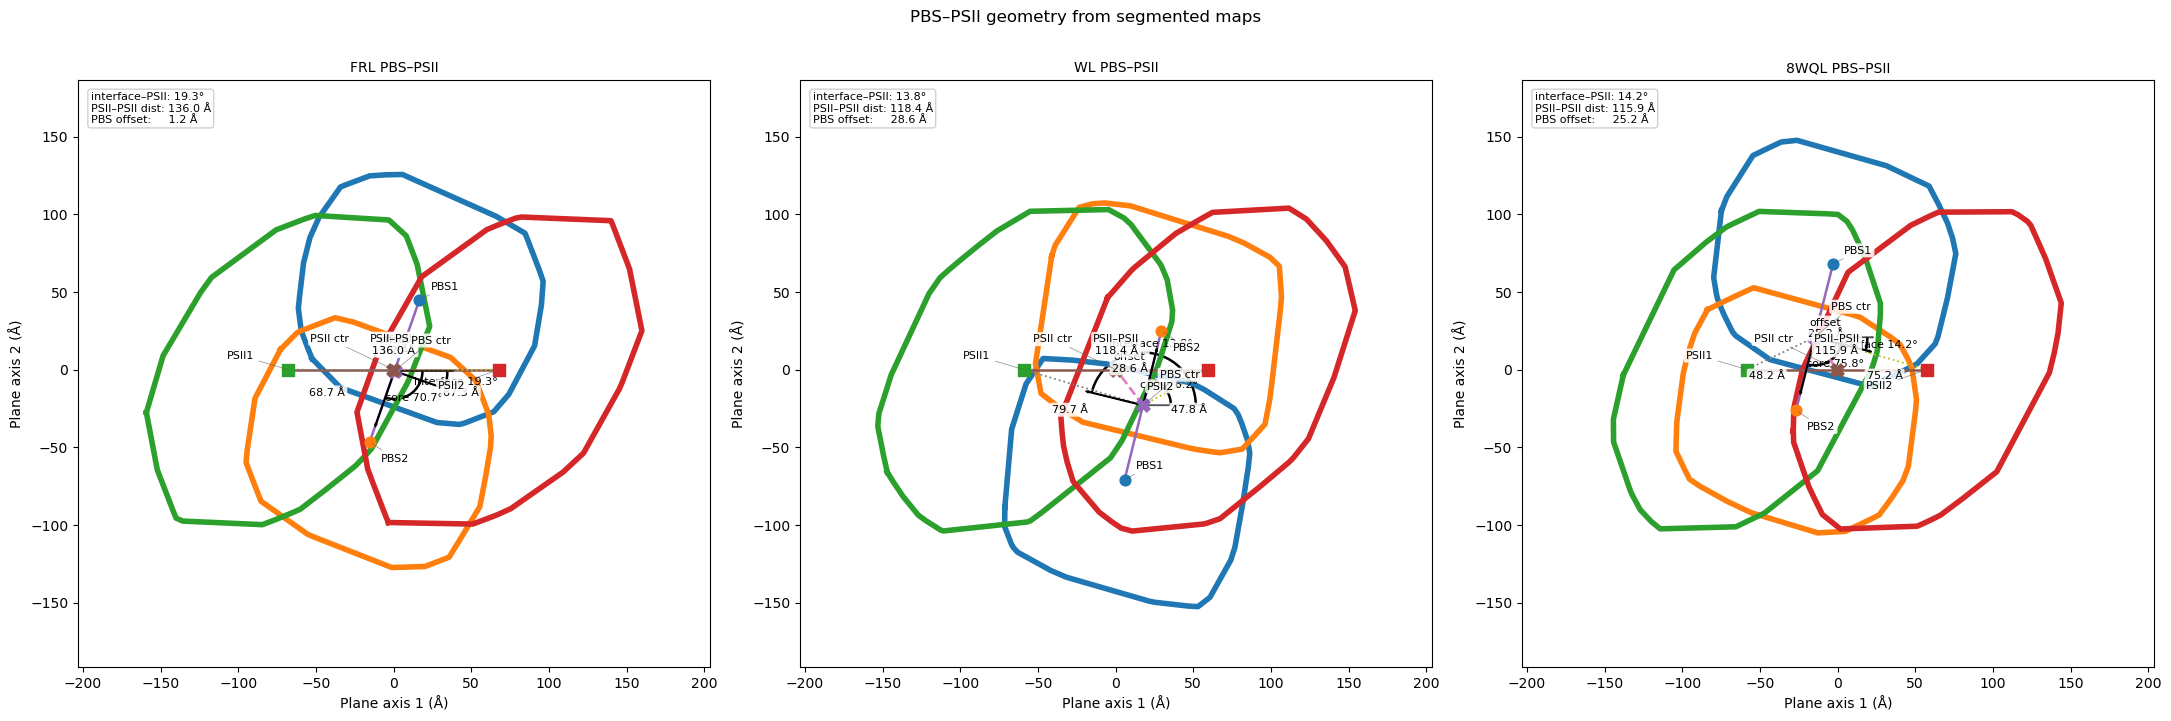

In [23]:
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7.2 * n, 7), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, results, plot_data in zip(axes, all_results, all_plots):
    plot_panel(ax, plot_data, results, title=results["label"])

# Match axis limits across panels
xmin = min(ax.get_xlim()[0] for ax in axes)
xmax = max(ax.get_xlim()[1] for ax in axes)
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)
xpad, ypad = 0.08 * (xmax - xmin), 0.08 * (ymax - ymin)
for ax in axes:
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

fig.suptitle("PBS–PSII geometry from segmented maps", y=1.02)
plt.show()

## 7. Save Outputs

In [ ]:
outdir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(outdir / "geometry_summary.tsv", sep="\t", index=False)
table.to_csv(outdir / "geometry_summary_display.tsv", sep="\t")

fig.savefig(outdir / "pbs_psii_geometry_comparison.pdf", dpi=300, bbox_inches="tight")
fig.savefig(outdir / "pbs_psii_geometry_comparison.svg", bbox_inches="tight")
fig.savefig(outdir / "pbs_psii_geometry_comparison.png", dpi=300, bbox_inches="tight")

print(f"Saved outputs to: {outdir.resolve()}")